# **Multi-Energy Consumption Analysis and Electricity Demand Prediction in India**

## Introduction

Energy consumption is a key indicator of economic development and societal behavior. In India, energy usage varies due to seasonal changes, industrial growth, population, and cultural activities such as festivals.

This project focuses on:
- Analyzing electricity consumption across Indian states (time-series data)
- Integrating petroleum consumption data (fuel energy)
- Understanding behavioral and seasonal impacts on energy usage
- Building machine learning models to predict electricity consumption
- Extending the system into a multi-energy analysis framework

This approach provides a more realistic and holistic understanding of energy consumption patterns in India.

# I**MPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **LOAD ELECTRICITY DATA**

In [2]:
df = pd.read_csv("Indias_Electricity_Consumption_Dataset.csv")
df.head()

,Unnamed: 0,Dates,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,Total Consumption
0,0,2013-01-06,251.5,1.6,21.3,40.9,3.8,60.3,5.8,66.0,...,95.2,192.0,1.7,254.5,127.6,2.6,225.0,33.6,107.5,2845.7
1,1,2013-01-07,257.9,1.7,21.2,39.6,3.8,64.3,5.8,67.2,...,92.8,192.9,1.8,262.3,129.2,2.6,219.1,34.2,106.6,2876.7
2,2,2013-01-08,265.1,1.6,20.4,39.2,3.9,63.0,5.9,66.7,...,93.9,197.1,1.8,256.6,131.9,2.1,238.7,33.9,103.9,2923.0
3,3,2013-01-09,261.0,1.6,21.4,39.5,3.7,65.0,5.8,67.4,...,90.1,197.6,1.9,254.6,135.0,2.7,229.1,32.7,105.7,2912.1
4,4,2013-01-10,260.0,1.6,21.1,39.7,3.8,66.5,5.9,67.8,...,93.5,199.9,1.9,255.3,130.0,3.2,224.5,35.4,105.3,2920.8


# **ELECTRICITY DATA CLEANING**

In [28]:
df = pd.read_csv("Indias_Electricity_Consumption_Dataset.csv")

# Drop unnecessary column
df.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')

# Convert Dates
df['Dates'] = pd.to_datetime(df['Dates'])

# Set index
df.set_index('Dates', inplace=True)

# Sort
df.sort_index(inplace=True)

# Impute missing values with the mean for numerical columns
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())

df.head()

,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,DNH,DVC,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,Total Consumption
Dates,,,,,,,,,,,,,,,,,,,,,
2013-01-06,251.5,1.6,21.3,40.9,3.8,60.3,5.8,66.0,15.0,56.2,...,95.2,192.0,1.7,254.5,127.6,2.6,225.0,33.6,107.5,2845.7
2013-01-07,257.9,1.7,21.2,39.6,3.8,64.3,5.8,67.2,15.1,59.9,...,92.8,192.9,1.8,262.3,129.2,2.6,219.1,34.2,106.6,2876.7
2013-01-08,265.1,1.6,20.4,39.2,3.9,63.0,5.9,66.7,15.2,60.3,...,93.9,197.1,1.8,256.6,131.9,2.1,238.7,33.9,103.9,2923.0
2013-01-09,261.0,1.6,21.4,39.5,3.7,65.0,5.8,67.4,15.2,60.0,...,90.1,197.6,1.9,254.6,135.0,2.7,229.1,32.7,105.7,2912.1
2013-01-10,260.0,1.6,21.1,39.7,3.8,66.5,5.9,67.8,14.9,58.9,...,93.5,199.9,1.9,255.3,130.0,3.2,224.5,35.4,105.3,2920.8


# **ELECTRICITY DATA INFO**

In [30]:
print("Shape:", df.shape)
print(df.info())

Shape: (3707, 37)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3707 entries, 2013-01-06 to 2024-09-29
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Andhra Pradesh     3707 non-null   float64
 1   Arunachal Pradesh  3707 non-null   float64
 2   Assam              3707 non-null   float64
 3   Bihar              3707 non-null   float64
 4   Chandigarh         3707 non-null   float64
 5   Chhattisgarh       3707 non-null   float64
 6   DD                 3707 non-null   float64
 7   Delhi              3707 non-null   float64
 8   DNH                3707 non-null   float64
 9   DVC                3707 non-null   float64
 10  Essar steel        3707 non-null   float64
 11  Goa                3707 non-null   float64
 12  Gujarat            3707 non-null   float64
 13  Haryana            3707 non-null   float64
 14  HP                 3707 non-null   float64
 15  J&K                3707 non-null   f

# **ELECTRICITY EDA**

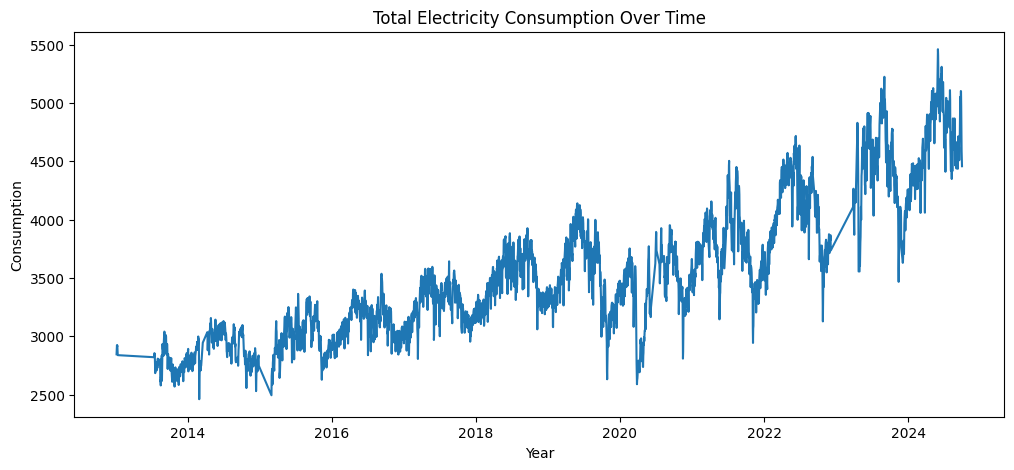

In [31]:
plt.figure(figsize=(12,5))
plt.plot(df['Total Consumption'])
plt.title("Total Electricity Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.show()

The electricity consumption dataset contains daily consumption data across Indian states.
The trend shows seasonal fluctuations due to weather conditions and varying demand.

# **LOAD FUEL DATA (PPAC)**

In [32]:
fuel_df = pd.read_excel("/content/Domestic Consumption of Petroleum Product in India by PPAC (FY1998-99 to FY2024-25).xlsx")
fuel_df.head()

,PRODUCTS,Financial Year,Year,Month,Month Name,Consumption in Metric Tonne
0,LPG,2024-25,2024,4,APR,2373
1,LPG,2024-25,2024,5,MAY,2410
2,LPG,2024-25,2024,6,JUN,2320
3,LPG,2024-25,2024,7,JUL,2649
4,LPG,2024-25,2024,8,AUG,2664


# **FUEL DATA CLEANING**

In [34]:
fuel_df = pd.read_excel("/content/Domestic Consumption of Petroleum Product in India by PPAC (FY1998-99 to FY2024-25).xlsx")
fuel_df.head()

,PRODUCTS,Financial Year,Year,Month,Month Name,Consumption in Metric Tonne
0,LPG,2024-25,2024,4,APR,2373
1,LPG,2024-25,2024,5,MAY,2410
2,LPG,2024-25,2024,6,JUN,2320
3,LPG,2024-25,2024,7,JUL,2649
4,LPG,2024-25,2024,8,AUG,2664


# **SELECT IMPORTANT FUEL COLUMN**

In [35]:
fuel_df.reset_index(inplace=True)
# Create a proper monthly date column
fuel_df['Date'] = pd.to_datetime(fuel_df['Year'].astype(str) + '-' + fuel_df['Month'].astype(str), format='%Y-%m')
fuel_df.set_index('Date', inplace=True)

# Pivot the table to make products as columns
fuel_df_pivoted = fuel_df.pivot_table(index='Date', columns='PRODUCTS', values='Consumption in Metric Tonne')

# Select the desired columns (LPG, MS, HSD)
fuel_df = fuel_df_pivoted[['LPG', 'MS', 'HSD']]
fuel_df.head()

PRODUCTS,LPG,MS,HSD
Date,,,
1998-04-01,394.0,448.0,3193.0
1998-05-01,393.0,490.0,3274.0
1998-06-01,381.0,462.0,3193.0
1998-07-01,438.0,451.0,2921.0
1998-08-01,415.0,450.0,2625.0


# **FUEL EDA**

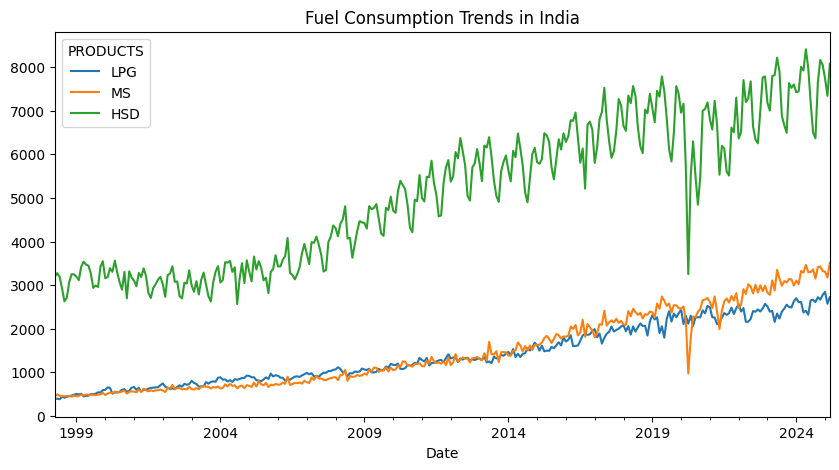

In [36]:
fuel_df.plot(figsize=(10,5), title="Fuel Consumption Trends in India")
plt.show()

Fuel consumption shows a steady increasing trend over the years, indicating growth in transportation, industrial activity, and household energy usage.

# **ALIGN BOTH DATASETS**

In [37]:
# Convert electricity to yearly
electric_yearly = df.resample('YE').mean()

# Convert fuel data to yearly, aligning with electricity data's index frequency
fuel_yearly = fuel_df.resample('YE').mean()

# Merge
combined_df = electric_yearly.join(fuel_yearly, how='inner')

combined_df.head()

,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,DNH,DVC,...,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,Total Consumption,LPG,MS,HSD
2013-12-31,235.809150,1.356209,22.535294,39.911111,4.271242,60.037255,5.885621,76.604575,14.643137,56.258824,...,237.456209,130.183007,2.931373,220.113072,30.840523,114.614379,2771.381699,1321.416667,1407.666667,5720.166667
2014-12-31,157.322917,1.679514,21.958333,48.058333,4.487500,68.403472,5.900000,80.269792,14.967708,55.522917,...,257.790278,128.130556,2.877778,238.780208,33.335069,126.553819,2902.645139,1472.500000,1532.083333,5751.833333
2015-12-31,136.633333,1.486667,23.086316,60.048421,4.596491,75.711228,6.363860,83.849474,15.775439,57.909825,...,265.535439,134.431579,3.279298,256.105614,35.263158,135.956842,3011.026667,1586.833333,1757.416667,6055.500000
2016-12-31,146.725000,1.901111,24.315556,65.445556,4.517778,74.655833,6.541667,82.890000,16.368889,59.918611,...,291.630833,139.372778,3.687882,277.303889,35.519444,134.044444,3128.411944,1769.250000,1971.833333,6395.083333
2017-12-31,154.896419,2.073829,24.792562,70.264463,4.423967,79.514601,6.842975,85.624793,16.656474,63.852066,...,286.922039,160.449311,3.719908,318.068595,35.992562,130.398072,3279.638017,1911.833333,2116.000000,6608.166667


# **COMBINED EDA**

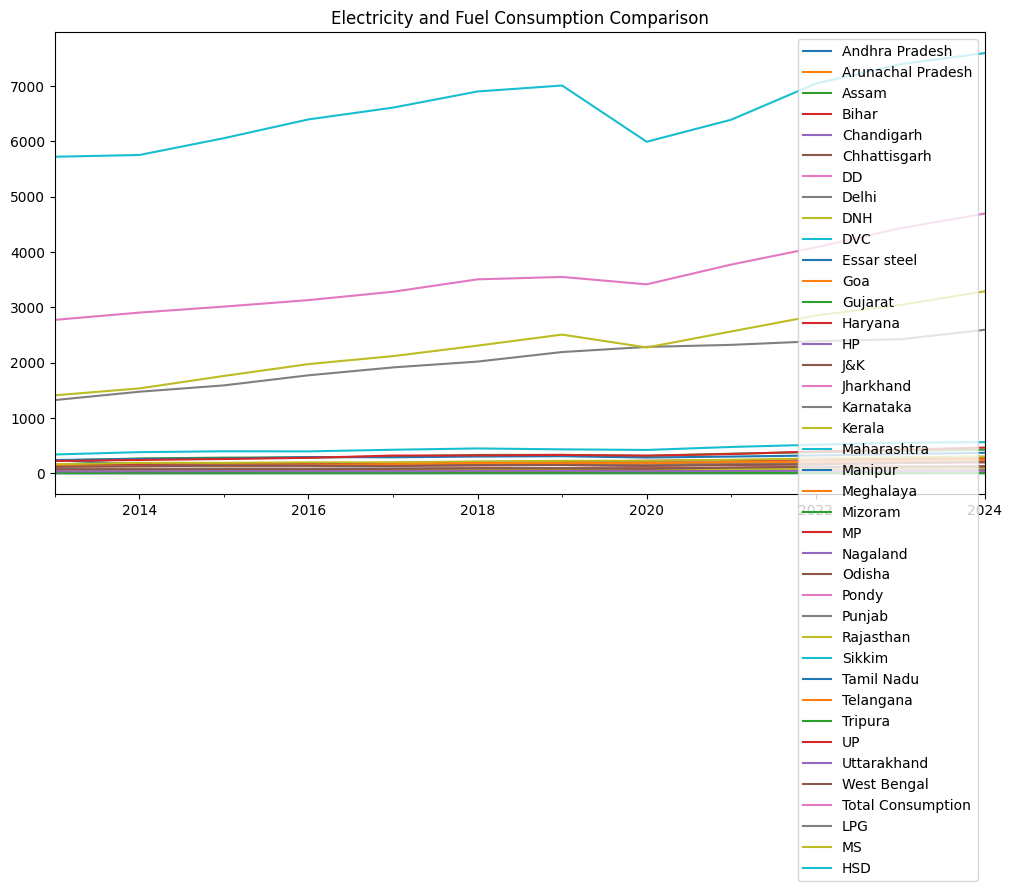

In [38]:
combined_df.plot(figsize=(12,6), title="Electricity and Fuel Consumption Comparison")
plt.show()

The combined analysis shows that both electricity and fuel consumption increase over time, reflecting economic development and increased energy demand.

# **FEATURE ENGINEERING**

In [39]:
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter

# **FESTIVAL MAPPING**

In [40]:
festival_map = {
    1: "Winter",
    2: "Winter",
    3: "Holi",
    4: "Summer",
    5: "Peak Summer",
    6: "Peak Summer",
    7: "Monsoon",
    8: "Monsoon",
    9: "Ganesh Festival",
    10: "Navratri",
    11: "Diwali",
    12: "Winter"
}

df['festival'] = df['month'].map(festival_map)

**FESTIVAL ANALYSIS**

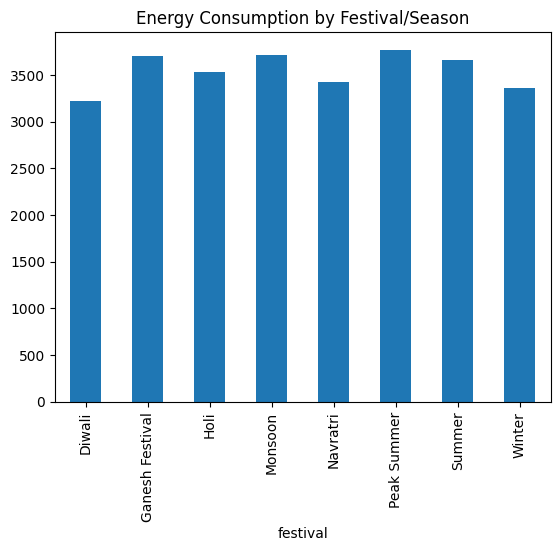

In [41]:
festival_usage = df.groupby('festival')['Total Consumption'].mean()

festival_usage.plot(kind='bar', title="Energy Consumption by Festival/Season")
plt.show()

Energy consumption peaks during summer and festival periods such as Diwali due to increased appliance usage and lighting.

**STATE ANALYSIS**

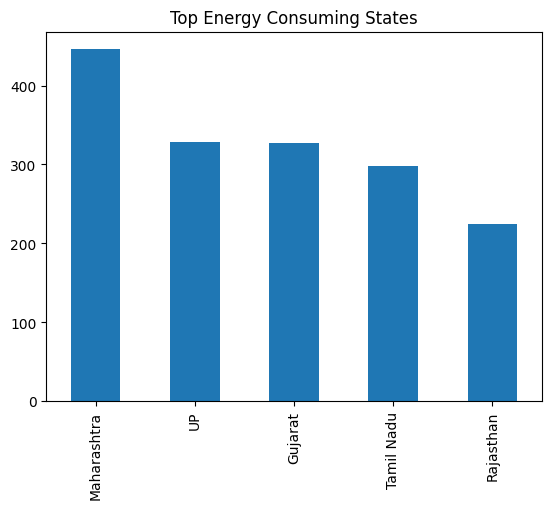

In [42]:
state_usage = df.drop(['Total Consumption','month','year','quarter','festival'], axis=1).mean()

top_states = state_usage.sort_values(ascending=False).head(5)

top_states.plot(kind='bar', title="Top Energy Consuming States")
plt.show()

# **MODELING**

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop('Total Consumption', axis=1)
y = df['Total Consumption']

# Identify categorical features to encode
categorical_features = ['festival']

# Create a ColumnTransformer to apply OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other numerical columns as they are
)

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
other_features = [col for col in X.columns if col not in categorical_features]
all_feature_names = list(encoded_feature_names) + list(other_features)

# Convert the processed array back to a DataFrame
X = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

**LINEAR REGRESSION**

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))

LR MAE: 26.04029799152269


**RANDOM FOREST**

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))

RF MAE: 306.37530807207787


**DECISION TREE**

In [46]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT MAE:", mean_absolute_error(y_test, y_pred_dt))

DT MAE: 379.50403838491405


# **LSTM**

In [47]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler = MinMaxScaler()
data = scaler.fit_transform(df[['Total Consumption']])

# create sequences
X_lstm, y_lstm = [], []
for i in range(10, len(data)):
    X_lstm.append(data[i-10:i])
    y_lstm.append(data[i])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_lstm.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_lstm, y_lstm, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0301
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0020
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014
Epoch 9/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014
Epoch 10/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013


## **Conclusion**

- Electricity consumption increases during summer and festivals
- Fuel consumption shows long-term growth due to economic development
- Behavioral and cultural factors significantly impact energy usage
- Machine learning models can effectively predict electricity demand
- Multi-energy integration provides a holistic understanding of energy systems